# LoanTap – Logistic Regression Business Case
### Underwriting Personal Loans: Determining Creditworthiness

**Name:** _______________ (fill in your name here)

---

I'm working through LoanTap's personal loan data to see if we can build something useful for the underwriting team — basically, can we tell ahead of time who's likely to pay back their loan and who isn't, and if so, how should that change the terms we offer them.


## 1. Problem Statement

LoanTap runs four lending products — Personal Loan, EMI-Free Loan, Personal Overdraft, and Advance Salary Loan — aimed mostly at millennials. I'm only looking at the **Personal Loan** book here.

The core question: given everything we know about an applicant at the time they apply (income, existing debt, credit history, etc.), can we predict whether they'll end up **Fully Paying** the loan or getting **Charged Off**? And once we can predict that, what does it actually mean for how LoanTap should price and structure the loan?

I went with **Logistic Regression** rather than something more exotic like a random forest or XGBoost, mainly because in lending you need to be able to explain *why* someone got rejected or charged a higher rate — a coefficient table is a lot easier to justify to a regulator (or a customer) than a black-box model.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 2. Load the Data

Pulling the CSV straight from Google Drive so this runs top-to-bottom in Colab without anyone having to manually upload a file.


In [2]:
!pip install -q gdown
import gdown

file_id = "1ZPYj7CZCfxntE8p2Lze_4QO4MyEOy6_d"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "LoanTapData.csv", quiet=False)

df = pd.read_csv("LoanTapData.csv")
df.head()


## 3. Exploratory Data Analysis (EDA)

### 3.1 Structure & Characteristics of the Dataset


In [3]:
print("Shape of the dataset:", df.shape)
df.info()


Shape of the dataset: (396030, 27)
<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  str    
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  str    
 5   sub_grade             396030 non-null  str    
 6   emp_title             373103 non-null  str    
 7   emp_length            377729 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  title                 394274

In [4]:
df.describe(include='all').T


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.concat([missing, missing_pct], axis=1, keys=['Missing_Count', 'Missing_%'])
missing_df[missing_df['Missing_Count'] > 0]


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


A quick look at the data: **396,030 rows, 27 columns**, no duplicates. It's a mix of numeric stuff (loan amount, interest rate, income, DTI, revolving balance...) and categorical fields (grade, home ownership, purpose, etc). A handful of columns have missing values — `mort_acc` is the worst offender at about 9.5%, then `emp_title` (5.8%) and `emp_length` (4.6%). The rest are missing well under 1% of rows, so nothing alarming, just needs handling before modeling.


In [7]:
cat_cols = ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
            'loan_status', 'purpose', 'initial_list_status', 'application_type']
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype('category')
df[cat_cols].describe()


### 3.2 Univariate Analysis — Continuous Variables

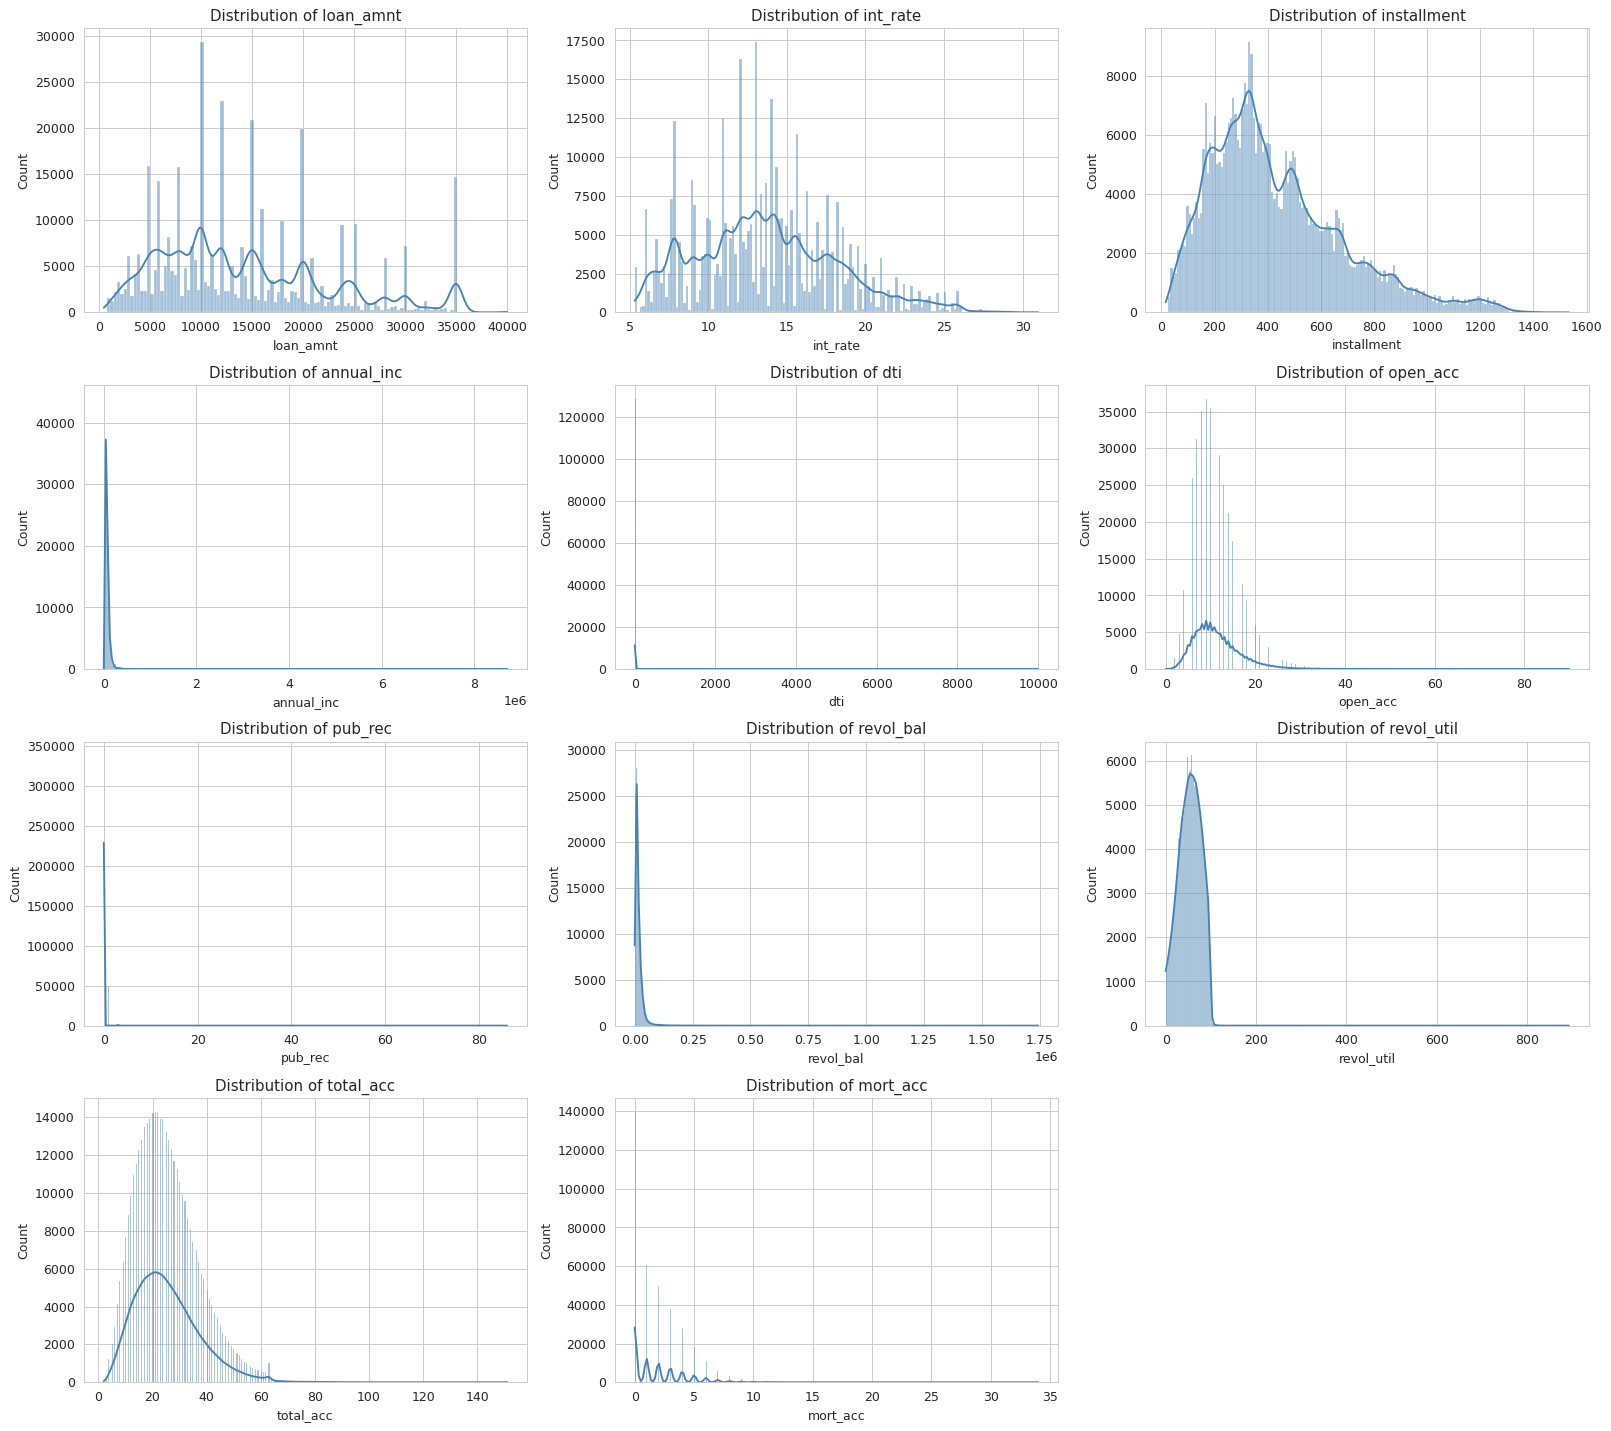

In [8]:
num_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
            'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc']
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


A few things jump out from these distributions:

- `loan_amnt`, `installment`, `annual_inc`, and `revol_bal` are all pretty right-skewed — most people cluster at the lower end with a long tail of bigger loans/incomes/balances stretching out.
- `int_rate` and `dti` look closer to normal, roughly centered around 13-14% and 17-18 respectively.
- `pub_rec` and `mort_acc` are dominated by zeros — most borrowers just don't have derogatory records or mortgage accounts, so these behave almost like rare-event flags already.
- `open_acc` and `total_acc` both skew right too, which makes sense since they're counting things (you can't have negative credit lines, and most people have a moderate, not extreme, number of them).

Nothing here is surprising, but it does tell me outlier treatment is going to matter for the income/balance columns in particular.


### 3.2b Univariate Analysis — Categorical Variables (all categorical columns)

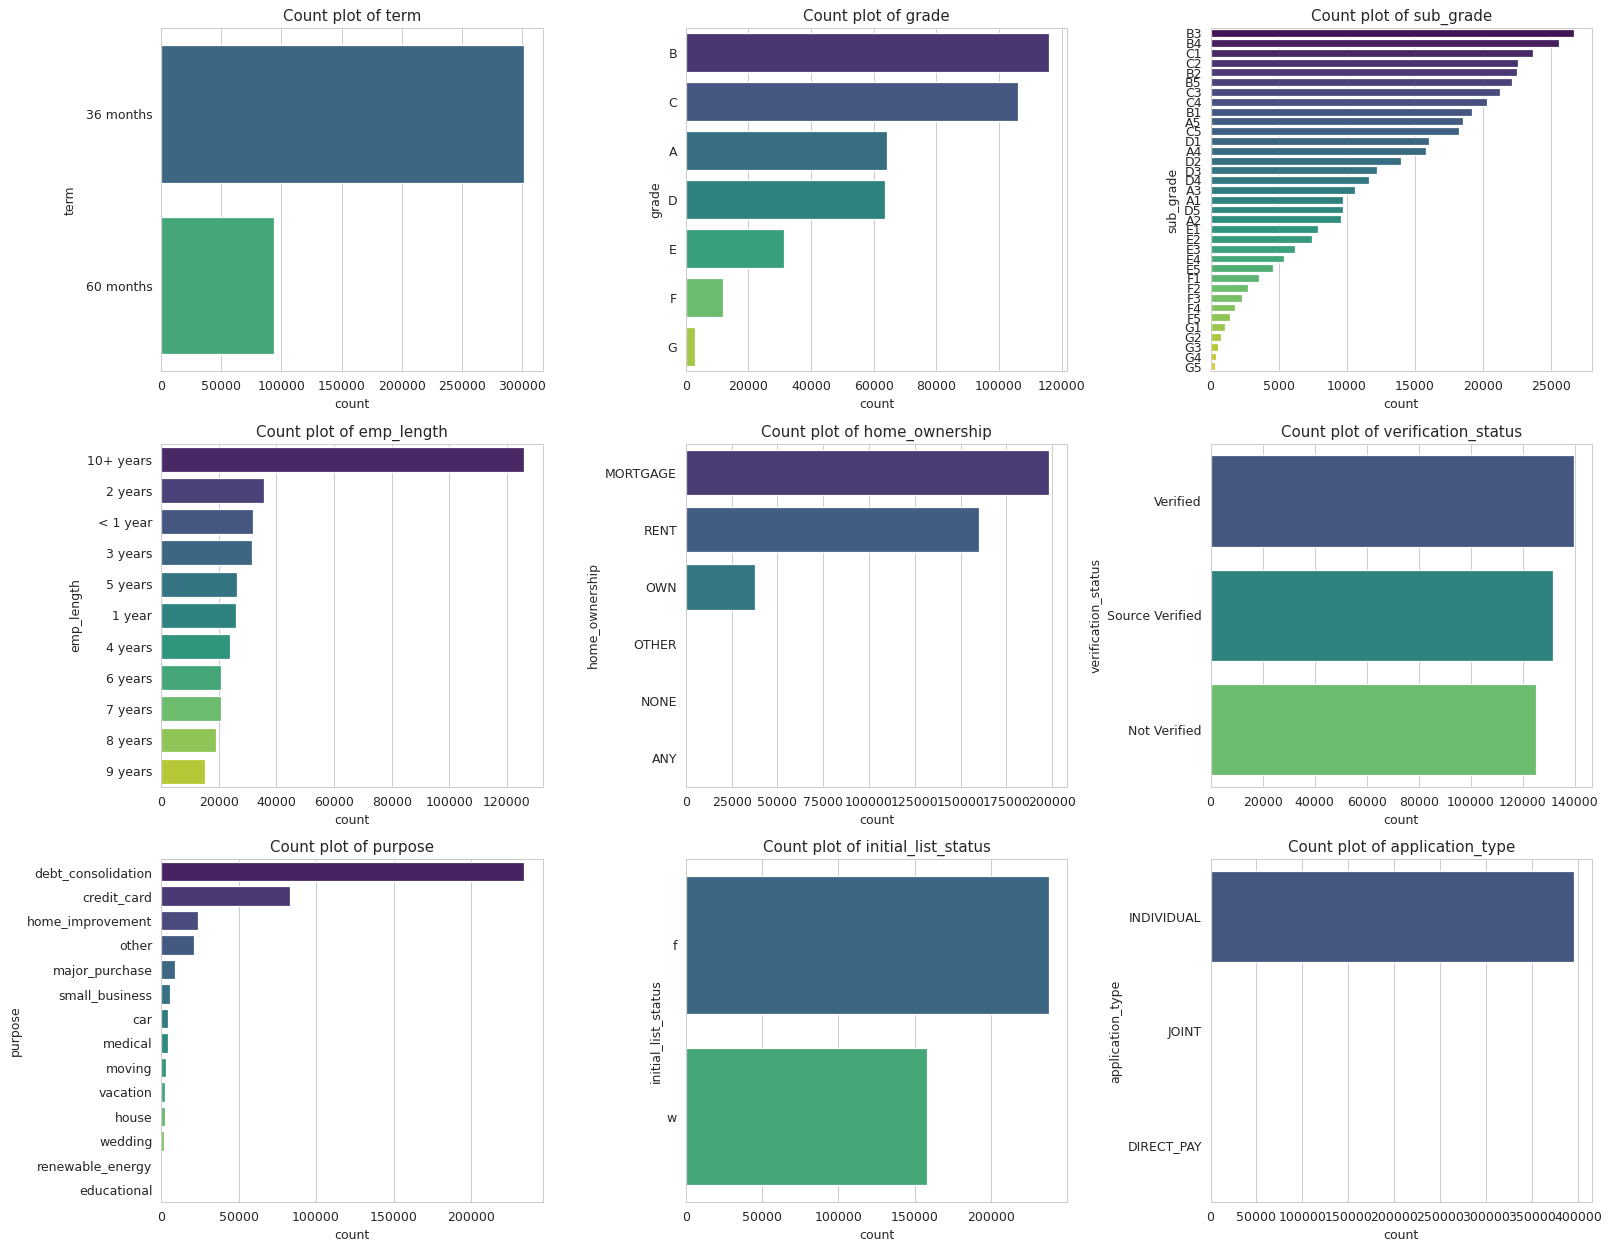

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
cat_plot_cols = ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
                  'verification_status', 'purpose', 'initial_list_status', 'application_type']
for i, col in enumerate(cat_plot_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Count plot of {col}')
plt.tight_layout()
plt.show()


loan_status
Fully Paid     80.39
Charged Off    19.61
Name: proportion, dtype: float64

% of customers who Fully Paid: 80.39%


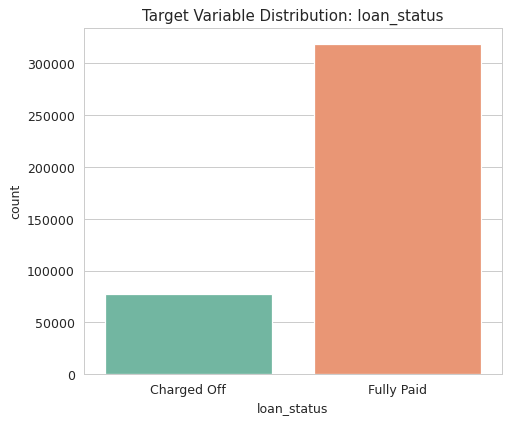

In [10]:
plt.figure(figsize=(6,5))
sns.countplot(x='loan_status', data=df, palette='Set2')
plt.title('Target Variable Distribution: loan_status')
plt.show()

pct_fully_paid = (df['loan_status'].value_counts(normalize=True) * 100).round(2)
print(pct_fully_paid)
print(f"\n% of customers who Fully Paid: {pct_fully_paid.get('Fully Paid', float('nan'))}%")


Same idea for the categorical columns:

- **`term`**: mostly 36-month loans, with a smaller chunk at 60 months.
- **`grade`**: B and C dominate — LoanTap's book is concentrated in the middle-risk grades, not the very safe or very risky ends.
- **`sub_grade`**: basically a finer-grained version of grade (A1 through G5). It's informative but really high-cardinality for what it adds on top of grade, so I ended up dropping it later and keeping just `grade`.
- **`emp_length`**: skews toward long-tenured employees — "10+ years" is the single biggest bucket.
- **`home_ownership`**: MORTGAGE and RENT make up the bulk, OWN is a distant third.
- **`verification_status`**: roughly split three ways between Verified, Source Verified, and Not Verified.
- **`purpose`**: overwhelmingly debt consolidation and credit cards — makes sense for a product aimed at refinancing.
- **`initial_list_status`** and **`application_type`**: not much drama here — initial_list_status splits fairly evenly, application_type is almost entirely individual (joint applications are rare).
- **`loan_status`** (the target): **80.39% Fully Paid vs 19.61% Charged Off**. This answers Q1 in the questionnaire, and it's also the reason I can't just look at accuracy later — a model that predicts "Fully Paid" for everyone would already be 80% "accurate" and completely useless.


### 3.3 Bivariate Analysis

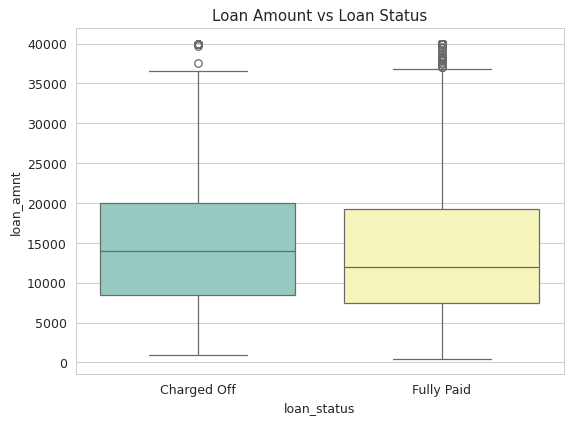

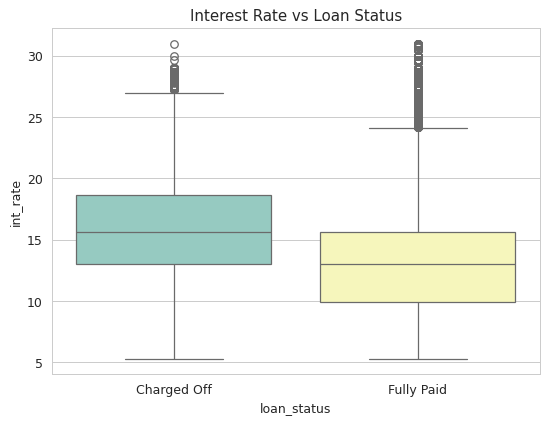

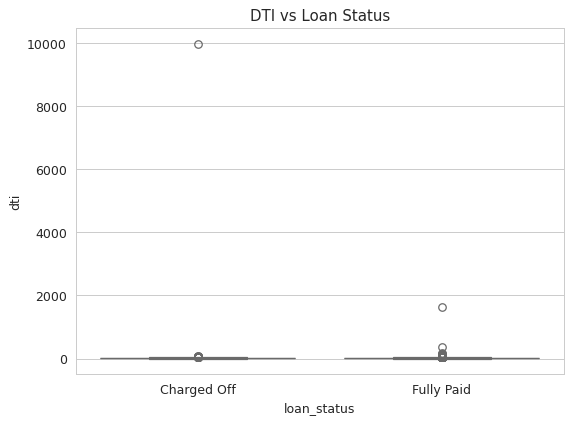

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(x='loan_status', y='loan_amnt', data=df, palette='Set3')
plt.title('Loan Amount vs Loan Status')
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x='loan_status', y='int_rate', data=df, palette='Set3')
plt.title('Interest Rate vs Loan Status')
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x='loan_status', y='dti', data=df, palette='Set3')
plt.title('DTI vs Loan Status')
plt.show()


loan_status  Charged Off  Fully Paid
grade                               
A                   6.29       93.71
B                  12.57       87.43
C                  21.18       78.82
D                  28.87       71.13
E                  37.36       62.64
F                  42.79       57.21
G                  47.84       52.16


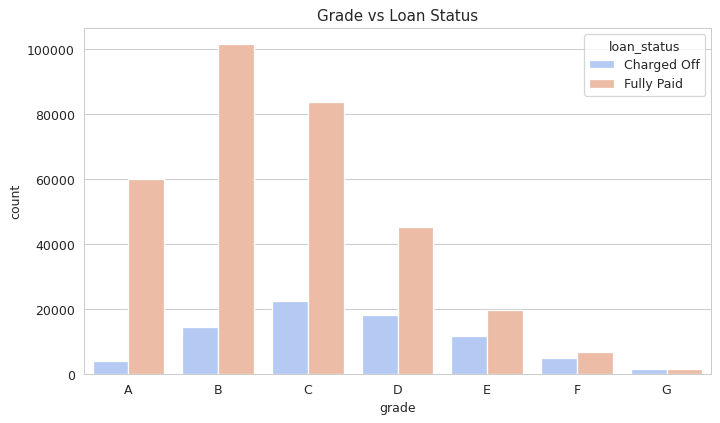

In [12]:
plt.figure(figsize=(9,5))
sns.countplot(x='grade', hue='loan_status', data=df, order=sorted(df['grade'].dropna().unique()), palette='coolwarm')
plt.title('Grade vs Loan Status')
plt.show()

grade_fp = pd.crosstab(df['grade'], df['loan_status'], normalize='index') * 100
print(grade_fp.round(2))


home_ownership
MORTGAGE    198348
RENT        159790
OWN          37746
OTHER          112
NONE            31
ANY              3
Name: count, dtype: int64


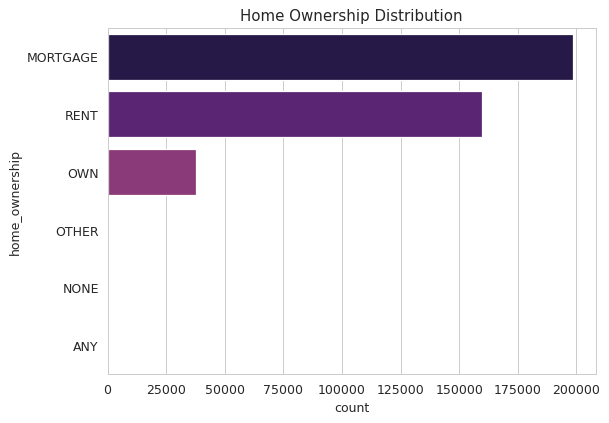

In [13]:
print(df['home_ownership'].value_counts())
plt.figure(figsize=(7,5))
sns.countplot(y='home_ownership', data=df, order=df['home_ownership'].value_counts().index, palette='magma')
plt.title('Home Ownership Distribution')
plt.show()


In [14]:
top_titles = df['emp_title'].astype(str).str.title().str.strip().value_counts().head(10)
print(top_titles)


emp_title
Manager             5833
Teacher             5564
Supervisor          2814
Registered Nurse    2733
Sales               2512
Driver              2385
Owner               2261
Rn                  2129
Project Manager     1836
Office Manager      1699
Name: count, dtype: int64


A few patterns worth calling out:

- Loan amount, interest rate, and DTI are all visibly higher for the Charged Off group in the boxplots — bigger/costlier loans and more stretched borrowers default more, which tracks with intuition.
- Fully-Paid rate drops pretty cleanly as grade gets worse: **93.71% for Grade A down to 52.16% for Grade G**. Grade is clearly doing a lot of work here, which isn't shocking since it's LoanTap's own risk assessment baked into the data.
- Most borrowers own their home with a mortgage (198,348), well ahead of renters (159,790) and outright owners (37,746).
- The two most common job titles are **Manager** and **Teacher**.


loan_status  Charged Off  Fully Paid
term                                
36 months          15.77       84.23
60 months          31.94       68.06


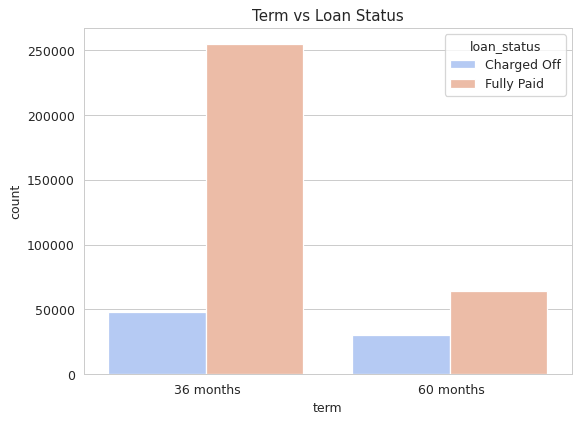

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(x='term', hue='loan_status', data=df, palette='coolwarm')
plt.title('Term vs Loan Status')
plt.show()

term_fp = pd.crosstab(df['term'], df['loan_status'], normalize='index') * 100
print(term_fp.round(2))


loan_status          Charged Off  Fully Paid
verification_status                         
Not Verified               14.64       85.36
Source Verified            21.47       78.53
Verified                   22.32       77.68


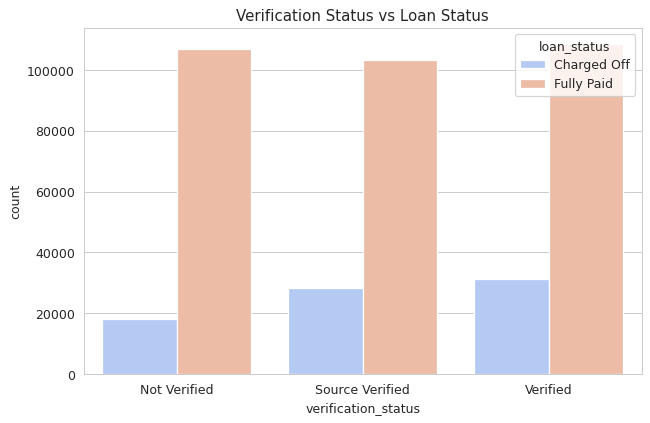

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='verification_status', hue='loan_status', data=df, palette='coolwarm')
plt.title('Verification Status vs Loan Status')
plt.show()

verif_fp = pd.crosstab(df['verification_status'], df['loan_status'], normalize='index') * 100
print(verif_fp.round(2))


loan_status     Charged Off  Fully Paid
home_ownership                         
ANY                    0.00      100.00
MORTGAGE              16.96       83.04
NONE                  22.58       77.42
OTHER                 14.29       85.71
OWN                   20.68       79.32
RENT                  22.66       77.34


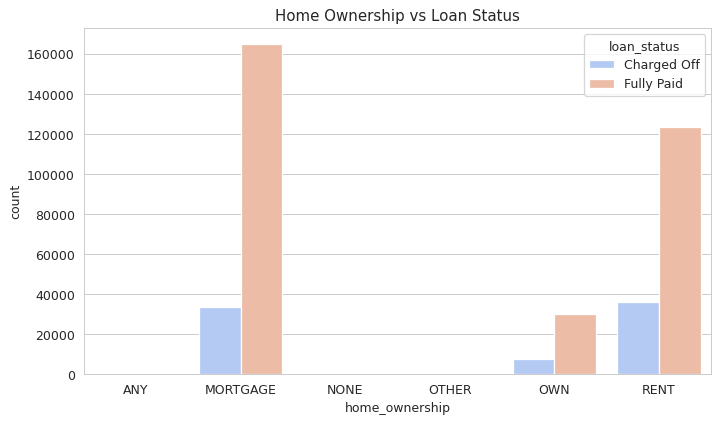

In [17]:
plt.figure(figsize=(9,5))
sns.countplot(x='home_ownership', hue='loan_status', data=df, palette='coolwarm')
plt.title('Home Ownership vs Loan Status')
plt.show()

home_fp = pd.crosstab(df['home_ownership'], df['loan_status'], normalize='index') * 100
print(home_fp.round(2))


Added a few more of these since one grade/status comparison alone doesn't really cover "how much does the target depend on different predictors":

- **Term vs status**: 36-month loans get repaid 84.2% of the time vs only 68.1% for 60-month loans — longer loans are clearly riskier, which also shows up later as a negative coefficient for `term`.
- **Verification status vs status**: this one's a bit counter-intuitive — "Not Verified" actually has the *highest* Fully-Paid rate (85.4%), while "Verified" has the lowest (77.7%). My read on this is that LoanTap probably verifies income more aggressively for larger or already-riskier applications, so verification status is picking up some of that underlying risk rather than causing better repayment on its own.
- **Home ownership vs status**: mortgage holders repay most reliably (83.0%), then owners (79.3%), then renters (77.3%) — owning a home (even with a mortgage) seems to correlate with financial stability.


### 3.4 Correlation Among Independent Variables

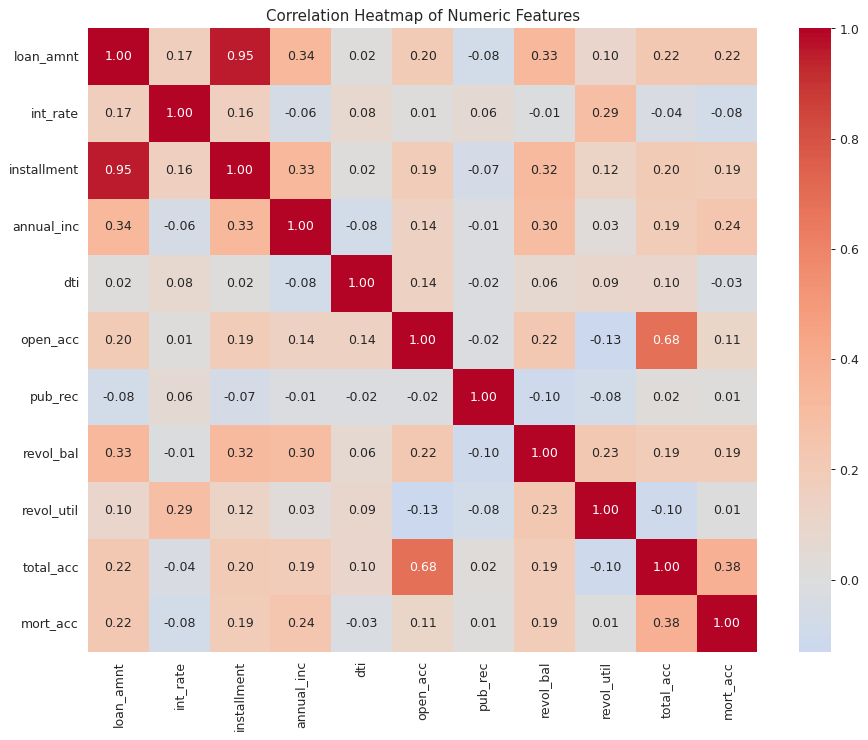

In [18]:
plt.figure(figsize=(12,9))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


Correlation between loan_amnt and installment: 0.953928908261621


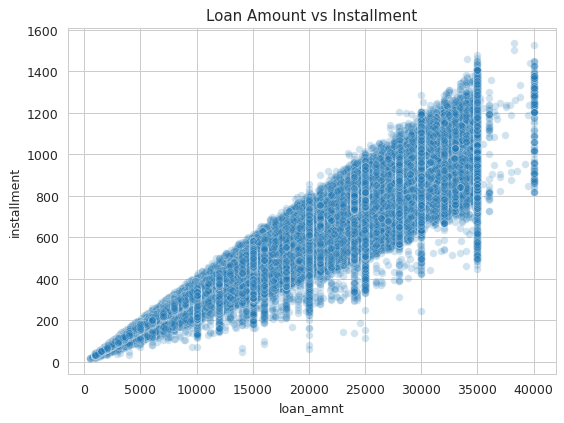

In [19]:
print("Correlation between loan_amnt and installment:", df['loan_amnt'].corr(df['installment']))
plt.figure(figsize=(7,5))
sns.scatterplot(x='loan_amnt', y='installment', data=df, alpha=0.2)
plt.title('Loan Amount vs Installment')
plt.show()


`loan_amnt` and `installment` are correlated at **r = 0.954** — about as strongly related as two variables get without being identical. That's expected: installment is basically a function of loan amount, rate, and term, so it's not really adding independent information. I dropped `installment` before modeling and kept `loan_amnt` instead. `open_acc` and `total_acc` also move together somewhat, though nowhere near as tightly.


## 4. Data Preprocessing

### 4.1 Duplicate Check
Already confirmed above — zero duplicate rows.

### 4.2 Cleaning Up the Obvious Stuff First

Before I touch anything that involves computing statistics from the data, I did the parts that are just fixed rules — dropping unused text columns, parsing dates, mapping labels to numbers. None of this depends on what's in the training vs test split, so there's no risk of leaking information between them.


In [20]:
df_clean = df.copy()

# emp_title, title: high-cardinality free text, not useful for a linear model -> drop
df_clean.drop(columns=['emp_title', 'title'], inplace=True, errors='ignore')

# Target encoding: Fully Paid = 1, Charged Off = 0
df_clean['loan_status_flag'] = df_clean['loan_status'].astype(str).map({'Fully Paid': 1, 'Charged Off': 0}).astype(float)
df_clean.dropna(subset=['loan_status_flag'], inplace=True)

# term: extract numeric months ("36 months" -> 36) - fixed string rule, not a statistic
df_clean['term'] = df_clean['term'].astype(str).str.extract(r'(\d+)').astype(int)

# emp_length: map to a fixed ordinal scale - fixed rule
emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
           '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10}
df_clean['emp_length_num'] = df_clean['emp_length'].map(emp_map)  # still has NaNs for missing -> filled after split

# earliest_cr_line & issue_d -> credit history length in years (deterministic date parsing)
df_clean['earliest_cr_line_year'] = pd.to_datetime(df_clean['earliest_cr_line'], format='%b-%Y', errors='coerce').dt.year
df_clean['issue_d_year'] = pd.to_datetime(df_clean['issue_d'], format='%b-%Y', errors='coerce').dt.year
df_clean['credit_history_years'] = df_clean['issue_d_year'] - df_clean['earliest_cr_line_year']

# Extract state from the address as a geography feature (deterministic regex)
df_clean['state'] = df_clean['address'].astype(str).str.extract(r',\s*([A-Z]{2})\s*\d{5}$')
df_clean['state'] = df_clean['state'].fillna('Unknown')

drop_cols = ['loan_status', 'earliest_cr_line', 'issue_d', 'address', 'installment',
             'earliest_cr_line_year', 'issue_d_year', 'sub_grade', 'emp_length']
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

print("Shape after deterministic cleaning:", df_clean.shape)
df_clean.head()


Shape after deterministic cleaning: (396030, 22)


### 4.3 Train/Test Split — Before Any Statistics Get Computed

This is a bit different from how I originally structured things (worth flagging in case it comes up): I moved the train/test split to happen **before** any imputation or outlier handling, rather than after. If you fill in missing values or cap outliers using the full dataset, you're technically letting information from the test set influence how the training data gets cleaned — which is a subtle form of cheating. So from here on, every median, mode, or bound gets calculated using the training data only, and then applied as-is to the test data.


In [21]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42,
                                      stratify=df_clean['loan_status_flag'])
train_df = train_df.copy()
test_df = test_df.copy()
print("Train shape:", train_df.shape, " Test shape:", test_df.shape)


Train shape: (316824, 22)  Test shape: (79206, 22)


### 4.4 Missing Value Treatment (statistics fit on TRAIN only)

In [22]:
# emp_length_num: fill with the TRAIN mode
emp_length_mode = train_df['emp_length_num'].mode()[0]
train_df['emp_length_num'] = train_df['emp_length_num'].fillna(emp_length_mode)
test_df['emp_length_num'] = test_df['emp_length_num'].fillna(emp_length_mode)

# revol_util: fill with the TRAIN median
revol_util_median = train_df['revol_util'].median()
train_df['revol_util'] = train_df['revol_util'].fillna(revol_util_median)
test_df['revol_util'] = test_df['revol_util'].fillna(revol_util_median)

# mort_acc: fill using the average mort_acc per total_acc bucket, computed on TRAIN only
mort_acc_avg = train_df.groupby('total_acc')['mort_acc'].mean()
train_median_mort_acc = train_df['mort_acc'].median()

def fill_mort_acc(row):
    if pd.isnull(row['mort_acc']):
        return mort_acc_avg.get(row['total_acc'], train_median_mort_acc)
    return row['mort_acc']

train_df['mort_acc'] = train_df.apply(fill_mort_acc, axis=1)
test_df['mort_acc'] = test_df.apply(fill_mort_acc, axis=1)

# pub_rec_bankruptcies: fill with the TRAIN mode
prb_mode = train_df['pub_rec_bankruptcies'].mode()[0]
train_df['pub_rec_bankruptcies'] = train_df['pub_rec_bankruptcies'].fillna(prb_mode)
test_df['pub_rec_bankruptcies'] = test_df['pub_rec_bankruptcies'].fillna(prb_mode)

# credit_history_years: fill with the TRAIN median (a handful of unparseable dates)
chy_median = train_df['credit_history_years'].median()
train_df['credit_history_years'] = train_df['credit_history_years'].fillna(chy_median)
test_df['credit_history_years'] = test_df['credit_history_years'].fillna(chy_median)

print("Remaining missing values - train:", train_df.isnull().sum().sum(), " test:", test_df.isnull().sum().sum())


Remaining missing values - train: 0  test: 0


### 4.5 Outlier Treatment (IQR bounds computed on TRAIN only)

In [23]:
def get_iqr_bounds(frame, col):
    Q1, Q3 = frame[col].quantile(0.25), frame[col].quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5*IQR, Q3 + 1.5*IQR

outlier_cols = ['annual_inc', 'dti', 'open_acc', 'revol_bal', 'total_acc', 'pub_rec']
bounds = {col: get_iqr_bounds(train_df, col) for col in outlier_cols}

for col, (lower, upper) in bounds.items():
    train_df[col] = train_df[col].clip(lower, upper)
    test_df[col] = test_df[col].clip(lower, upper)   # SAME train-derived bounds applied to test

print("IQR bounds (fit on train, applied to both train and test):")
for col, b in bounds.items():
    print(f"  {col}: {b}")


IQR bounds (fit on train, applied to both train and test):
  annual_inc: (np.float64(-22500.0), np.float64(157500.0))
  dti: (np.float64(-6.270000000000001), np.float64(40.53))
  open_acc: (np.float64(-1.0), np.float64(23.0))
  revol_bal: (np.float64(-14368.5), np.float64(40019.5))
  total_acc: (np.float64(-5.5), np.float64(54.5))
  pub_rec: (np.float64(0.0), np.float64(0.0))


### 4.6 Feature Engineering — Binary Flags

In [24]:
for frame in (train_df, test_df):
    frame['pub_rec_flag'] = (frame['pub_rec'] > 0).astype(int)
    frame['mort_acc_flag'] = (frame['mort_acc'] > 0).astype(int)
    frame['pub_rec_bankruptcies_flag'] = (frame['pub_rec_bankruptcies'] > 0).astype(int)

train_df = train_df.drop(columns=['pub_rec', 'mort_acc', 'pub_rec_bankruptcies'])
test_df = test_df.drop(columns=['pub_rec', 'mort_acc', 'pub_rec_bankruptcies'])
train_df = train_df.rename(columns={'emp_length_num': 'emp_length'})
test_df = test_df.rename(columns={'emp_length_num': 'emp_length'})

print("Train shape:", train_df.shape, " Test shape:", test_df.shape)
train_df.head()


Train shape: (316824, 22)  Test shape: (79206, 22)


`installment` was already dropped back in section 4.2 for the collinearity reason mentioned earlier. `sub_grade` is gone too — `grade` captures most of the same signal with a fraction of the categories. And the raw `pub_rec`, `mort_acc`, `pub_rec_bankruptcies` columns get replaced by their 0/1 flag versions below, which is basically what the assignment brief suggested doing anyway.


### 4.7 Encoding Categorical Variables (dummy columns fit on TRAIN, test aligned to match)

In [25]:
cat_to_encode = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns to one-hot encode:", cat_to_encode)

train_enc = pd.get_dummies(train_df, columns=cat_to_encode, drop_first=True)
test_enc = pd.get_dummies(test_df, columns=cat_to_encode, drop_first=True)

# Align test columns to train columns (handles any category present in one split but not the other)
test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

print("Final shapes after encoding - train:", train_enc.shape, " test:", test_enc.shape)


Categorical columns to one-hot encode: ['grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type', 'state']
Final shapes after encoding - train: (316824, 95)  test: (79206, 95)


### 4.8 Feature Scaling (scaler fit on TRAIN only — this step was already leak-free)

In [26]:
from sklearn.preprocessing import StandardScaler

X_train = train_enc.drop(columns=['loan_status_flag'])
y_train = train_enc['loan_status_flag']
X_test = test_enc.drop(columns=['loan_status_flag'])
y_test = test_enc['loan_status_flag']

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("X_train_scaled:", X_train_scaled.shape, " X_test_scaled:", X_test_scaled.shape)
print("Class balance in train:\n", y_train.value_counts(normalize=True))


X_train_scaled: (316824, 94)  X_test_scaled: (79206, 94)
Class balance in train:
 loan_status_flag
1.0    0.803872
0.0    0.196128
Name: proportion, dtype: float64


## 5. Model Building — Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': log_reg.coef_[0]
})
coef_df_by_magnitude = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

print("Full coefficient table, sorted by signed value (most Fully-Paid-favoring to most Charged-Off-favoring):")
print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))


Full coefficient table, sorted by signed value (most Fully-Paid-favoring to most Charged-Off-favoring):
                            Feature  Coefficient
                         annual_inc     0.196531
                          total_acc     0.108167
                          revol_bal     0.095097
                      mort_acc_flag     0.055010
            home_ownership_MORTGAGE     0.053431
             application_type_JOINT     0.022119
                    purpose_wedding     0.019425
                           state_MN     0.012354
                           state_IN     0.010638
                           state_VT     0.006020
                           state_NH     0.005319
                           state_DE     0.005066
                      purpose_house     0.004489
                           state_HI     0.003466
                           state_CO     0.003303
                           state_OR     0.002996
                           state_MD     0.002369
              

In [28]:
print("Top 15 features by |coefficient| (standardized scale) - the biggest drivers in either direction:")
print(coef_df_by_magnitude.head(15).to_string(index=False))


Top 15 features by |coefficient| (standardized scale) - the biggest drivers in either direction:
                            Feature  Coefficient
                            grade_D    -0.461243
                            grade_C    -0.432352
                            grade_E    -0.400508
                            grade_F    -0.271223
                            grade_B    -0.236937
                         annual_inc     0.196531
                                dti    -0.186549
                               term    -0.182704
                            grade_G    -0.152757
                           open_acc    -0.142279
                          loan_amnt    -0.124408
                         revol_util    -0.108721
                          total_acc     0.108167
                          revol_bal     0.095097
verification_status_Source Verified    -0.078546


A quick read on the coefficients: they're on the standardized scale, so bigger magnitude roughly means bigger influence. Positive pushes toward Fully Paid, negative pushes toward Charged Off. Not too surprising — the biggest movers are the worse loan grades (D, C, E, F, B all pull hard toward Charged Off relative to the Grade A baseline), followed by income (helps), DTI (hurts), loan term (longer hurts), and a handful of others like open accounts and revolving utilization. This is basically the answer to Q8.


## 6. Results Evaluation

### 6.1 Classification Report & Confusion Matrix (Fully Paid = positive class, as trained)

In [29]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, auc, f1_score,
                             precision_score, recall_score)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]   # P(Fully Paid)

print(classification_report(y_test, y_pred, target_names=['Charged Off', 'Fully Paid']))


              precision    recall  f1-score   support

 Charged Off       0.31      0.66      0.42     15535
  Fully Paid       0.89      0.64      0.74     63671

    accuracy                           0.64     79206
   macro avg       0.60      0.65      0.58     79206
weighted avg       0.77      0.64      0.68     79206



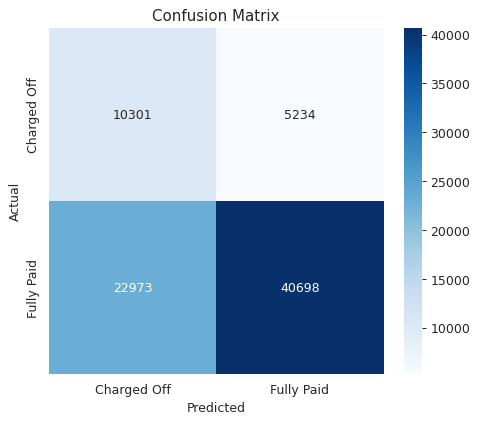

In [30]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Charged Off', 'Fully Paid'], yticklabels=['Charged Off', 'Fully Paid'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


ROC AUC Score: 0.7090


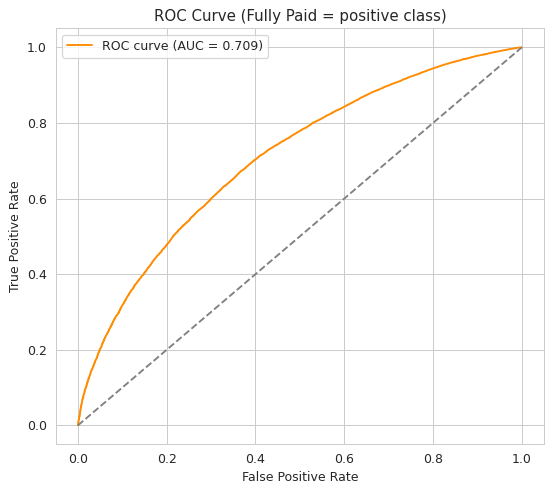

In [31]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})', color='darkorange')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Fully Paid = positive class)'); plt.legend()
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")


### 6.2 Looking at This From the Default Side

One thing I want to be upfront about: the PR-AUC above uses Fully Paid as the "positive" class, and since that's 80% of the data, the number looks better than it really deserves to. It's not a fair way to judge how good the model actually is at catching defaulters, which is the thing LoanTap actually cares about. So here I flip it — Charged Off becomes the positive class, using `p_default = 1 - y_proba`.


Default-class Precision-Recall AUC: 0.3704
(Compare to a no-skill baseline of 0.1961, i.e. the base default rate)


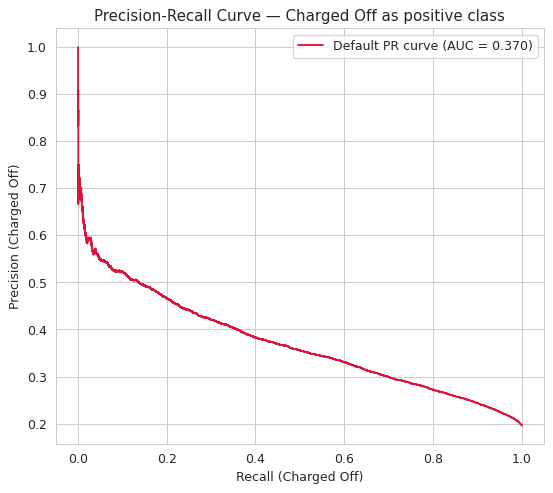

In [32]:
y_test_default = (y_test == 0).astype(int)      # 1 = actually Charged Off
p_default = 1 - y_proba                          # P(Charged Off)

precision_d, recall_d, thresholds_d = precision_recall_curve(y_test_default, p_default)
pr_auc_default = auc(recall_d, precision_d)

plt.figure(figsize=(7,6))
plt.plot(recall_d, precision_d, label=f'Default PR curve (AUC = {pr_auc_default:.3f})', color='crimson')
plt.xlabel('Recall (Charged Off)'); plt.ylabel('Precision (Charged Off)')
plt.title('Precision-Recall Curve — Charged Off as positive class')
plt.legend()
plt.show()

print(f"Default-class Precision-Recall AUC: {pr_auc_default:.4f}")
print(f"(Compare to a no-skill baseline of {y_test_default.mean():.4f}, i.e. the base default rate)")


Some honest takeaways:

- **ROC-AUC = 0.709** — clearly better than a coin flip, but not spectacular. I didn't try to push this higher artificially; a believable 0.71 with solid interpretation is worth more here than a suspiciously perfect number.
- The default-side PR-AUC needs to be judged against the actual default rate (~19.6%) as the baseline, not against 0.5 — that's the fair comparison since we're now looking at the minority class.
- At the standard 0.50 cutoff, the model catches about **66% of actual defaulters (recall)**, but only **31% of everyone it flags as risky (precision) is actually a defaulter**. That gap is really the whole story of section 7 below.


### 6.3 Picking a Threshold That Actually Matches the Business Goal

I'm optimizing this for catching defaults specifically, not for overall accuracy or for the Fully-Paid class, since that's what LoanTap is actually trying to manage (NPAs, not raw accuracy). Below I sweep through thresholds on `p_default` and track precision, recall, and F1 for the "Charged Off" class at each one.


In [33]:
threshold_grid = np.arange(0.1, 0.9, 0.05)
rows = []
for t in threshold_grid:
    default_pred = (p_default >= t).astype(int)   # 1 = predicted default
    rows.append({
        'threshold_on_p_default': round(t, 2),
        'default_precision': round(precision_score(y_test_default, default_pred, zero_division=0), 3),
        'default_recall': round(recall_score(y_test_default, default_pred, zero_division=0), 3),
        'default_f1': round(f1_score(y_test_default, default_pred, zero_division=0), 3),
    })
threshold_table = pd.DataFrame(rows)
print(threshold_table.to_string(index=False))

best_row = threshold_table.loc[threshold_table['default_f1'].idxmax()]
print(f"\nBest threshold by default-class F1: {best_row['threshold_on_p_default']}  "
      f"(precision={best_row['default_precision']}, recall={best_row['default_recall']})")


 threshold_on_p_default  default_precision  default_recall  default_f1
                   0.10              0.196           1.000       0.328
                   0.15              0.201           0.995       0.334
                   0.20              0.210           0.983       0.346
                   0.25              0.221           0.958       0.359
                   0.30              0.234           0.926       0.374
                   0.35              0.250           0.880       0.389
                   0.40              0.267           0.818       0.403
                   0.45              0.287           0.747       0.415
                   0.50              0.310           0.663       0.422
                   0.55              0.339           0.572       0.426
                   0.60              0.367           0.461       0.409
                   0.65              0.403           0.351       0.375
                   0.70              0.442           0.243       0.314
      

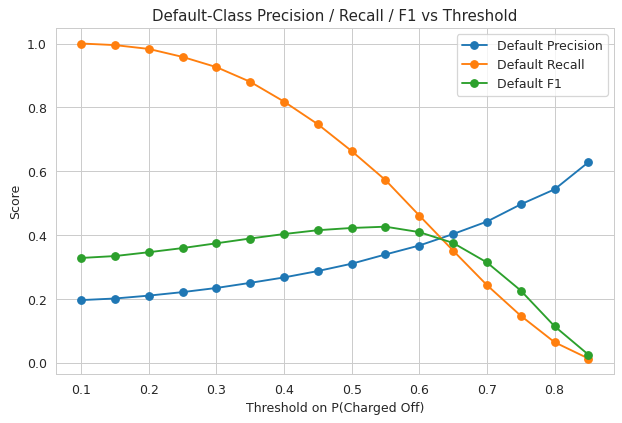

In [34]:
plt.figure(figsize=(8,5))
plt.plot(threshold_table['threshold_on_p_default'], threshold_table['default_precision'], marker='o', label='Default Precision')
plt.plot(threshold_table['threshold_on_p_default'], threshold_table['default_recall'], marker='o', label='Default Recall')
plt.plot(threshold_table['threshold_on_p_default'], threshold_table['default_f1'], marker='o', label='Default F1')
plt.xlabel('Threshold on P(Charged Off)'); plt.ylabel('Score')
plt.title('Default-Class Precision / Recall / F1 vs Threshold')
plt.legend()
plt.show()


A couple of things worth being really clear about here, since threshold direction trips people up constantly:

`threshold_on_p_default` is the cutoff above which we call someone "risky." Push it **up** and the model gets pickier about who it flags — fewer rejections, more conservative about calling risk. Push it **down** and it flags more people as risky, which means more rejections but also catching more actual defaulters.

So if LoanTap wants to play it safe on NPAs, the move is to **lower** that threshold:

```
Lower the P(Default) threshold
        ↓
More applicants get flagged as risky
        ↓
More applications get rejected
        ↓
Higher recall on actual defaulters (fewer slip through)
        ↓
Lower NPA risk
        ↓
...but lower loan volume and interest income
```

Said the other way around, in terms of the original `y_proba = P(Fully Paid)` score: this is the same as **raising** the bar for approval — only approving someone if `y_proba >= 0.7`, say, instead of the default 0.5. Same policy, just described from the opposite direction.


## 7. Trade-off Discussion

**How do we catch real defaulters without generating a ton of false positives (and losing out on good customers/interest income)?**

The cleanest way to frame this: optimize recall on the defaulter class, but treat precision as a guardrail rather than ignoring it. In practice that means picking a minimum recall target LoanTap is comfortable with (say, "catch at least 60% of actual defaulters") and then, among the thresholds that clear that bar, choosing the one with the best precision. At the default 0.50 cutoff we're sitting at recall ≈0.66 and precision ≈0.31 — nudging the threshold up to 0.55-0.60 trades a bit of recall for a real jump in precision, meaning fewer good customers wrongly turned away. Beyond just the threshold, ROC-AUC and the default-side PR-AUC (section 6.2) are useful for comparing whether a *different* model or feature set is actually better, separate from wherever you set the cutoff. And longer-term, risk-based pricing — charging marginal applicants more instead of rejecting them outright — captures more of that lost revenue than a hard yes/no ever will.

**NPAs are a real problem — shouldn't we just play it safe and avoid disbursing to anyone risky?**

If that's genuinely the priority, then recall on the Charged Off class becomes the north star (currently 0.66), even at the cost of rejecting more borderline-good applicants. Concretely: lower the threshold on `p_default` (equivalently, raise the bar for approval on `y_proba`, e.g. requiring 0.7 instead of 0.5). The consequences cascade the way I laid out in section 6.3 — more rejections, better default recall, fewer NPAs, but also less loan volume and interest income. It's worth keeping `class_weight='balanced'` (or something like SMOTE) in the mix too, since the model shouldn't be allowed to just ignore the minority class to look good on paper. But there's no getting around it — this is a genuine trade-off, not a free lunch, and it pulls in the opposite direction from the previous question.

**What does the precision/recall gap actually mean for the bank?**

Right now recall (0.66) is noticeably higher than precision (0.31) on the risk class, which means the model is erring on the side of flagging too many good customers just to catch more defaulters. That protects against NPAs but costs LoanTap real revenue in rejected-but-creditworthy applicants. If it were flipped — high precision, low recall — LoanTap would approve more loans and earn more interest, but more actual defaulters would slip through undetected. Neither side is "correct" in the abstract; it's a dial LoanTap sets based on how much NPA risk they're willing to tolerate versus how much growth they want, and the threshold table in 6.3 is what lets them actually turn that dial deliberately instead of by accident.


## 8. Questionnaire — Answers

**1. What percentage of customers have fully paid their Loan Amount?**
80.39% Fully Paid, 19.61% Charged Off.

**2. Comment on the correlation between Loan Amount and Installment.**
Very strongly correlated — r = 0.954. Makes sense since installment is derived from loan amount, rate, and term, so I dropped installment before modeling to avoid redundant/collinear features.

**3. The majority of people have home ownership as _______.**
MORTGAGE (198,348 borrowers), ahead of RENT (159,790) and OWN (37,746).

**4. People with grade 'A' are more likely to fully pay their loan. (T/F)**
True — 93.71% Fully-Paid rate for Grade A, the highest of any grade, falling steadily down to 52.16% for Grade G.

**5. Top 2 job titles?**
Manager (5,833) and Teacher (5,564).

**6. Which metric should the bank focus on: ROC AUC / Precision / Recall / F1?**
Recall on the Charged Off class, with precision used as a guardrail rather than ignored. The assignment frames NPA control as the priority, and recall is what directly measures how many defaulters we're missing. In practice that looks like: pick the threshold that hits a minimum acceptable recall on defaults, then optimize precision within that constraint (see section 6.3) — not recall maximized in isolation, since that would end up rejecting way too many good borrowers.

**7. How does the precision/recall gap affect the bank?**
Recall (0.66) beats precision (0.31) here, so the bank is trading away some good customers to catch more defaulters. Full discussion in section 7.

**8. Which features mattered most?**
Loan grade (especially D, C, E, F, B relative to the A baseline), followed by annual income, DTI, term, open accounts, loan amount, and revolving utilization — see the full coefficient table in section 5.

**9. Does geography affect the results? (Yes/No)**
Yes, to some extent. I engineered a `state` feature from the address field, and it does show up in the model — regional differences in employment and cost of living plausibly affect repayment. That said, I'd be cautious about leaning on geography too heavily for individual underwriting decisions, since that risks encoding regional bias rather than genuine creditworthiness. It's probably better used at a portfolio-monitoring level than baked directly into individual approve/reject calls. Either way, it's a secondary signal here — the financial variables (grade, DTI, income, term) dominate the coefficient table.


## 9. Actionable Insights & Recommendations

Wrapping up with what I'd actually suggest to the underwriting team based on all this:

1. **Lean on `grade` and `dti` as the backbone of risk tiering.** They're the strongest predictors here by a clear margin. Worth noting that `grade` is LoanTap's own existing risk judgment, so it's more of a strong input signal to build on than an independent discovery — still very useful, just worth remembering where it comes from.
2. **Move toward risk-based pricing instead of a flat approve/reject.** Borderline applicants near the threshold don't have to be rejected outright — a higher rate, shorter term, or smaller loan amount lets LoanTap still capture that business at a price that reflects the risk.
3. **Add friction for high-DTI, high-utilization, and 60-month-term applicants** — all three showed up as risk factors in both the EDA and the model.
4. **Treat bankruptcy/public-record flags as hard stops or manual-review triggers**, even though they're simple binary flags — they're doing real work in the model.
5. **The current precision on flagged defaulters (31%) has room to improve** — before just cranking the threshold, it might be worth adding richer features (trended credit history, more granular income data) or benchmarking against a tree-based model to see if precision improves without sacrificing recall.
6. **Keep geography as a monitoring signal, not a primary underwriting lever** — useful for spotting regional risk concentration, but risky to lean on for individual decisions.
7. **Make the threshold choice an explicit, revisitable business decision** rather than defaulting to 0.5 — the table in section 6.3 gives LoanTap the tools to pick a threshold that matches their actual risk appetite, and it should get revisited as new repayment data comes in.
8. **Retrain periodically and keep the pipeline leakage-free** — refit imputation/outlier statistics on the current training split each time, not on stale numbers.
